# WESAD Emotion Classification — Full End-to-End Notebook

This notebook contains the full runnable pipeline for emotion classification using the WESAD dataset (Chest + Wrist). It includes all code cells for preprocessing, EDA, training (LSTM), evaluation, tuning (Optuna/RandomSearch), and final retrain + publication artifacts.

**Important:** Place extracted WESAD `.pkl` files (S2.pkl ... S17.pkl) in `raw_wesad/` folder next to this notebook. Run cells sequentially. Use a virtual environment with the required packages (see requirements).

## Requirements

Run in a Python 3.10/3.11 environment. Install packages:
```
pip install numpy pandas scipy scikit-learn matplotlib seaborn torch torchvision tqdm joblib optuna
```
(Optuna optional; if not present notebook will fall back to Random Search.)

In [1]:
import sys, torch

print("Python", sys.version)
print("Torch", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print(
    "Device name:",
    torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
)

Python 3.10.18 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:08:55) [MSC v.1929 64 bit (AMD64)]
Torch 2.8.0+cu126
CUDA available: True
Device name: NVIDIA GeForce RTX 4060 Laptop GPU


## Step 1 — Data Preparation (Chest + Wrist, caching)

This cell processes each subject `.pkl`, extracts wrist and chest signals, downsamples to 4Hz, windows into 30s segments with 50% overlap, labels by majority, and saves compressed `.npz` per subject.

In [2]:
import os, json, pickle, warnings
from pathlib import Path
from collections import Counter
import numpy as np
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

RAW_DIR = Path("raw_wesad")
OUT_DIR = Path("data_preprocessed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_RATE, WINDOW_SEC, OVERLAP = 32, 10, 0.5
LABEL_MAP = {1: 0, 2: 1, 3: 2, 4: 3}
CLASS_NAMES = {0: "baseline", 1: "stress", 2: "amusement", 3: "meditation"}


# ---------- Utility Functions ----------
def block_downsample_1d(arr, factor, agg="mean"):
    if factor <= 1 or len(arr) < factor:
        return arr.copy()
    arr = arr[: len(arr) // factor * factor].reshape(-1, factor)
    return arr.mean(axis=1) if agg == "mean" else np.median(arr, axis=1)


def acc_magnitude(acc):
    return np.linalg.norm(acc, axis=1) if acc.size else np.array([], np.float32)


def majority_label(labels):
    valid = labels[labels != -1]
    if len(valid) == 0:
        return -1
    label, count = Counter(valid).most_common(1)[0]
    return label if count / len(labels) >= 0.4 else -1


def ds_factor(src, tgt):
    return max(1, round(src / tgt))


def ensure_len(a, n):
    return a[:n] if a.size else np.zeros(n, np.float32)


# ---------- Core Processing ----------
def process_single_subject(path: Path, out_dir: Path):
    print(f"\nProcessing {path.name}...")
    with open(path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    wrist, chest = data["signal"].get("wrist", {}), data["signal"].get("chest", {})
    labels = np.array(data.get("label", []), np.int32).flatten()
    mapped_labels = np.array([LABEL_MAP.get(int(l), -1) for l in labels])

    print(f"  Raw labels: {dict(Counter(labels))}")
    print(f"  Valid mapped: {np.sum(mapped_labels != -1)}/{len(labels)}")

    # Extract & downsample signals
    wrist_signals = {
        "acc": acc_magnitude(np.array(wrist.get("ACC", []))),
        "eda": np.array(wrist.get("EDA", [])).flatten(),
        "temp": np.array(wrist.get("TEMP", [])).flatten(),
    }
    chest_signals = {
        "ecg": np.array(chest.get("ECG", [])).flatten(),
        "resp": np.array(chest.get("RESP", [])).flatten(),
        "acc": acc_magnitude(np.array(chest.get("ACC", []))),
        "eda": np.array(chest.get("EDA", [])).flatten(),
        "temp": np.array(chest.get("TEMP", [])).flatten(),
    }

    src_rates = dict(
        wrist_acc=32,
        wrist_eda=4,
        wrist_temp=4,
        chest_ecg=700,
        chest_resp=700,
        chest_acc=700,
        chest_eda=700,
        chest_temp=700,
        label=700,
    )

    # Downsample all
    ds = lambda arr, rate: block_downsample_1d(arr, ds_factor(rate, TARGET_RATE))
    wrist_ds = {k: ds(v, src_rates[f"wrist_{k}"]) for k, v in wrist_signals.items()}
    chest_ds = {k: ds(v, src_rates[f"chest_{k}"]) for k, v in chest_signals.items()}
    labels_ds = block_downsample_1d(
        mapped_labels, ds_factor(700, TARGET_RATE), "median"
    ).astype(int)

    # Sync & stack
    arrays = list(wrist_ds.values()) + list(chest_ds.values()) + [labels_ds]
    min_len = min(map(len, [a for a in arrays if len(a) > 0]))
    if not min_len:
        print("  ERROR: No valid data.")
        return None

    for k in wrist_ds:
        wrist_ds[k] = ensure_len(wrist_ds[k], min_len)
    for k in chest_ds:
        chest_ds[k] = ensure_len(chest_ds[k], min_len)
    labels_ds = labels_ds[:min_len]

    X = np.stack([*wrist_ds.values(), *chest_ds.values()], axis=1, dtype=np.float32)

    # Create sliding windows
    seq_len = int(WINDOW_SEC * TARGET_RATE)
    step = int(seq_len * (1 - OVERLAP))
    windows, y, meta = [], [], []

    for i in range(0, len(X) - seq_len + 1, step):
        seg_y = majority_label(labels_ds[i : i + seq_len])
        if seg_y != -1:
            windows.append(X[i : i + seq_len])
            y.append(seg_y)
            meta.append((i, i + seq_len))

    if not windows:
        print("  WARNING: No valid windows.")
        return None

    X, y, meta = np.stack(windows), np.array(y), np.array(meta)
    print(f"  Saved {len(X)} windows -> {dict(Counter(y))}")

    out_path = out_dir / f"{path.stem}_combined.npz"
    np.savez_compressed(out_path, X=X, y=y, meta=meta)
    return out_path


# ---------- Batch Processing ----------
pkl_files = sorted(RAW_DIR.glob("S*.pkl"))
print(f"Found {len(pkl_files)} subjects:", [p.name for p in pkl_files])

saved = []
for p in tqdm(pkl_files, desc="Processing subjects"):
    try:
        out = process_single_subject(p, OUT_DIR)
        if out:
            saved.append(out)
    except Exception as e:
        print(f"  ERROR processing {p.name}: {e}")

print(f"\n✓ Processed {len(saved)}/{len(pkl_files)} subjects.")

# ---------- Manifest Summary ----------
manifest = {}
for f in saved:
    arr = np.load(f)
    manifest[f.name] = {
        "X_shape": arr["X"].shape,
        "y_shape": arr["y"].shape,
        "class_counts": dict(Counter(arr["y"].tolist())),
    }

with open(OUT_DIR / "manifest.json", "w") as fh:
    json.dump(manifest, fh, indent=2)

print("\nSummary:")
for name, info in manifest.items():
    print(
        f"{name:25s} | {info['X_shape'][0]:4d} windows | classes={info['class_counts']}"
    )

c:\Users\indra\anaconda3\envs\deep_learning_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 15 subjects: ['S10.pkl', 'S11.pkl', 'S13.pkl', 'S14.pkl', 'S15.pkl', 'S16.pkl', 'S17.pkl', 'S2.pkl', 'S3.pkl', 'S4.pkl', 'S5.pkl', 'S6.pkl', 'S7.pkl', 'S8.pkl', 'S9.pkl']


Processing subjects:   0%|          | 0/15 [00:00<?, ?it/s]


Processing S10.pkl...


Processing subjects:   7%|▋         | 1/15 [00:03<00:43,  3.10s/it]

...


Processing S8.pkl...
  Raw labels: {np.int32(0): 1616300, np.int32(1): 818300, np.int32(5): 34300, np.int32(3): 258999, np.int32(7): 36400, np.int32(4): 557200, np.int32(2): 469000, np.int32(6): 35701}
  Valid mapped: 2103499/3826200
  Saved 104 windows -> {np.int64(0): 104}


Processing subjects:  93%|█████████▎| 14/15 [01:01<00:04,  4.62s/it]


Processing S9.pkl...
  Raw labels: {np.int32(0): 1435700, np.int32(1): 826000, np.int32(5): 42000, np.int32(2): 451500, np.int32(6): 43400, np.int32(4): 555100, np.int32(3): 260400, np.int32(7): 42000}
  Valid mapped: 2093000/3656100
  Saved 115 windows -> {np.int64(0): 115}


Processing subjects: 100%|██████████| 15/15 [01:05<00:00,  4.40s/it]



✓ Processed 15/15 subjects.

Summary:
S10_combined.npz          |  118 windows | classes={0: 118}
S11_combined.npz          |  113 windows | classes={0: 113}
S13_combined.npz          |  120 windows | classes={0: 120}
S14_combined.npz          |  132 windows | classes={0: 132}
S15_combined.npz          |  109 windows | classes={0: 109}
S16_combined.npz          |  120 windows | classes={0: 120}
S17_combined.npz          |  129 windows | classes={0: 129}
S2_combined.npz           |   90 windows | classes={0: 90}
S3_combined.npz           |   92 windows | classes={0: 92}
S4_combined.npz           |  103 windows | classes={0: 103}
S5_combined.npz           |  100 windows | classes={0: 100}
S6_combined.npz           |   48 windows | classes={0: 48}
S7_combined.npz           |  110 windows | classes={0: 110}
S8_combined.npz           |  104 windows | classes={0: 104}
S9_combined.npz           |  115 windows | classes={0: 115}


In [3]:
# DIAGNOSTIC ANALYSIS (Optimized)
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json
from pathlib import Path
from collections import Counter

# === Configuration ===
DATA_DIR = Path("data_preprocessed")
DIAG_DIR = Path("diagnostics")
DIAG_DIR.mkdir(parents=True, exist_ok=True)
CLASS_NAMES = {0: "baseline", 1: "stress", 2: "amusement", 3: "meditation"}

print("=" * 70)
print("DIAGNOSTIC ANALYSIS")
print("=" * 70)

# === Load Data ===
files = sorted(DATA_DIR.glob("*_combined.npz"))
print(f"\nFound {len(files)} subjects")

subject_stats, total_windows, overall_dist, quality_issues = [], 0, Counter(), []

# === Analyze Each Subject ===
for f in files:
    data = np.load(f)
    X, y, subj = data["X"], data["y"], f.stem
    n = len(y)
    total_windows += n
    dist = Counter(y.tolist())
    overall_dist.update(dist)

    # Subject summary
    subject_stats.append(
        {
            "subject": subj,
            "total_windows": n,
            **{CLASS_NAMES[k]: dist.get(k, 0) for k in CLASS_NAMES},
        }
    )

    # Quality check
    nan_count, inf_count = np.isnan(X).sum(), np.isinf(X).sum()
    constant_channels = [ch for ch in range(X.shape[2]) if X[:, :, ch].std() < 1e-6]

    if nan_count or inf_count or constant_channels:
        quality_issues.append(
            {
                "subject": subj,
                "nan_count": int(nan_count),
                "inf_count": int(inf_count),
                "constant_channels": constant_channels,
            }
        )

    print(f"{subj:15s}: {n:4d} windows | {dict(dist)}")

print(f"\n{'TOTAL':15s}: {total_windows:4d} windows")

# === Save Per-Subject Stats ===
df_stats = pd.DataFrame(subject_stats).fillna(0)
df_stats.to_csv(DIAG_DIR / "subject_statistics.csv", index=False)

# === Class Balance Summary ===
print("\n" + "=" * 70)
print("CLASS BALANCE SUMMARY")
print("=" * 70)

total = sum(overall_dist.values())
for cid, count in sorted(overall_dist.items()):
    print(f"{CLASS_NAMES[cid]:12s}: {count:5d} ({100*count/total:5.1f}%)")

counts = [overall_dist[i] for i in range(4)]
imbalance_ratio = max(counts) / max(1, min(counts))
print(f"\nImbalance ratio: {imbalance_ratio:.2f}x")

if imbalance_ratio > 10:
    print("⚠️ Severe imbalance → use Focal Loss / oversampling")
elif imbalance_ratio > 3:
    print("⚠️ Moderate imbalance → use class weights")
else:
    print("✅ Class balance acceptable")

# === Visualization ===
plt.figure(figsize=(10, 5))
classes = [CLASS_NAMES[i] for i in range(4)]
values = [overall_dist[i] for i in range(4)]
plt.subplot(1, 2, 1)
plt.bar(classes, values)
plt.title("Overall Class Distribution")
plt.ylabel("Windows")

plt.subplot(1, 2, 2)
df_stats.set_index("subject")[classes].plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Class Distribution per Subject")
plt.tight_layout()
plt.savefig(DIAG_DIR / "class_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

# === Data Quality ===
print("\n" + "=" * 70)
print("DATA QUALITY CHECKS")
print("=" * 70)

if not quality_issues:
    print("✅ No data quality issues detected")
else:
    print(f"⚠️ Issues found in {len(quality_issues)} subjects")
    for q in quality_issues:
        print(
            f"  {q['subject']}: NaN={q['nan_count']}, Inf={q['inf_count']}, Const={q['constant_channels']}"
        )
    json.dump(quality_issues, open(DIAG_DIR / "quality_issues.json", "w"), indent=2)

# === Recommendations ===
print("\n" + "=" * 70)
print("RECOMMENDATIONS")
print("=" * 70)

min_samples, min_per_class = 500, {CLASS_NAMES[i]: overall_dist[i] for i in range(4)}
low_classes = {k: v for k, v in min_per_class.items() if v < min_samples}

if low_classes:
    print("⚠️ Insufficient data per class (<500 samples):")
    for k, v in low_classes.items():
        print(f"   - {k}: {v} samples (need {min_samples - v} more)")
    print("💡 Use simpler models (SimpleLSTM), data augmentation, or higher overlap.")

if total_windows < 2000:
    print(
        f"\n⚠️ Very small dataset ({total_windows} windows) → use simple LSTM or classical ML."
    )
elif total_windows < 5000:
    print(
        f"\n⚠️ Small dataset ({total_windows} windows) → use regularization / CNN_LSTM."
    )
else:
    print(f"\n✅ Adequate dataset size ({total_windows} windows)")

# === LOSO Cross-Validation Feasibility ===
print("\n" + "=" * 70)
print("LOSO CROSS-VALIDATION CHECK")
print("=" * 70)

mins = df_stats["total_windows"].min()
avg = df_stats["total_windows"].mean()

print(f"Subjects: {len(files)} | Min windows: {mins} | Avg: {avg:.1f}")
if len(files) < 10:
    print("⚠️ Few subjects → prefer k-fold CV.")
elif mins < 50:
    print("⚠️ Some subjects have too few samples for LOSO.")
else:
    print("✅ LOSO setup feasible.")

# === Save Summary Report ===
summary = {
    "total_subjects": len(files),
    "total_windows": int(total_windows),
    "class_distribution": {k: int(v) for k, v in min_per_class.items()},
    "imbalance_ratio": float(imbalance_ratio),
    "min_windows_per_subject": int(mins),
    "avg_windows_per_subject": float(avg),
    "quality_issues": len(quality_issues),
    "recommendations": [],
}

if low_classes:
    summary["recommendations"].append("Simplify model or augment data")
if imbalance_ratio > 3:
    summary["recommendations"].append("Use Focal Loss or class weights")
if total_windows < 5000:
    summary["recommendations"].append("Data augmentation recommended")

json.dump(summary, open(DIAG_DIR / "summary_report.json", "w"), indent=2)
print("\n✅ Summary saved to:", DIAG_DIR)

DIAGNOSTIC ANALYSIS

Found 15 subjects
S10_combined   :  118 windows | {0: 118}
S11_combined   :  113 windows | {0: 113}
S13_combined   :  120 windows | {0: 120}
S14_combined   :  132 windows | {0: 132}
S15_combined   :  109 windows | {0: 109}
S16_combined   :  120 windows | {0: 120}
S17_combined   :  129 windows | {0: 129}
S2_combined    :   90 windows | {0: 90}
S3_combined    :   92 windows | {0: 92}
S4_combined    :  103 windows | {0: 103}
S5_combined    :  100 windows | {0: 100}
S6_combined    :   48 windows | {0: 48}
S7_combined    :  110 windows | {0: 110}
S8_combined    :  104 windows | {0: 104}
S9_combined    :  115 windows | {0: 115}

TOTAL          : 1603 windows

CLASS BALANCE SUMMARY
baseline    :  1603 (100.0%)

Imbalance ratio: 1603.00x
⚠️ Severe imbalance → use Focal Loss / oversampling

DATA QUALITY CHECKS
⚠️ Issues found in 15 subjects
  S10_combined: NaN=0, Inf=0, Const=[4, 7]
  S11_combined: NaN=0, Inf=0, Const=[4, 7]
  S13_combined: NaN=0, Inf=0, Const=[4, 7]
  S14_

## Step 2 — EDA (full code)

In [4]:
# ============================================================
# STEP 2: EXPLORATORY DATA ANALYSIS (Complete + Optimized)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Optional (for advanced EDA)
try:
    from umap import UMAP

    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

# ---------------- CONFIGURATION ----------------
DATA_DIR = Path("data_preprocessed")
OUT_DIR = Path("results_eda")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ADVANCED_EDA = True  # Toggle to False for faster runs

CLASS_NAMES = {0: "baseline", 1: "stress", 2: "amusement", 3: "meditation"}
CHANNEL_NAMES = [
    "wrist_ACCmag",
    "wrist_EDA",
    "wrist_TEMP",
    "chest_ECG",
    "chest_RESP",
    "chest_ACCmag",
    "chest_EDA",
    "chest_TEMP",
]

sns.set(style="whitegrid", context="talk")

print("=" * 80)
print("STEP 2: EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)

# ---------------- LOAD DATA ----------------
files = sorted(DATA_DIR.glob("*_combined.npz"))
if not files:
    print("⚠️ No preprocessed files found in", DATA_DIR)
    exit()

records = []
for f in files:
    arr = np.load(f)
    y = arr["y"]
    total = len(y)
    for k, v in Counter(y.tolist()).items():
        records.append(
            {
                "subject": f.stem,
                "class": CLASS_NAMES[k],
                "count": v,
                "pct": 100 * v / total,
            }
        )

summary_df = pd.DataFrame(records)
summary_df.to_csv(OUT_DIR / "class_summary_per_subject.csv", index=False)
print(f"✓ Loaded {len(files)} subjects. Summary saved.")

# =====================================================
# 1️⃣ OVERALL CLASS DISTRIBUTION
# =====================================================
plt.figure(figsize=(7, 4))
sns.barplot(
    data=summary_df, x="class", y="count", estimator=sum, ci=None, palette="muted"
)
plt.title("Overall Class Distribution")
plt.ylabel("Number of Windows")
plt.tight_layout()
plt.savefig(OUT_DIR / "class_distribution.png", dpi=300)
plt.close()

# =====================================================
# 2️⃣ PER-SUBJECT CLASS PROPORTIONS
# =====================================================
pivot = summary_df.pivot_table(
    values="pct", index="subject", columns="class", fill_value=0
)
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues")
plt.title("Per-Subject Class (%)")
plt.tight_layout()
plt.savefig(OUT_DIR / "class_subject_heatmap.png", dpi=300)
plt.close()

# =====================================================
# 3️⃣ CHANNEL STATS (SAMPLE SUBJECT)
# =====================================================
arr = np.load(files[0])
X, y = arr["X"], arr["y"]
stats = []
for cls in np.unique(y):
    Xi = X[y == cls]
    stats.extend(
        [
            {
                "class": CLASS_NAMES[cls],
                "channel": ch,
                "mean": float(Xi[..., i].mean()),
                "std": float(Xi[..., i].std()),
            }
            for i, ch in enumerate(CHANNEL_NAMES)
        ]
    )

stats_df = pd.DataFrame(stats)
stats_df.to_csv(OUT_DIR / "channel_stats_sample_subject.csv", index=False)

# Plot mean per channel
plt.figure(figsize=(10, 5))
sns.barplot(data=stats_df, x="channel", y="mean", hue="class", ci=None)
plt.title("Channel Mean Values (Sample Subject)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "channel_means.png", dpi=300)
plt.close()

# =====================================================
# 4️⃣ t-SNE / UMAP VISUALIZATION
# =====================================================
n = min(1500, len(y))
idx = np.random.choice(len(y), n, replace=False)
Xsub = X[idx].reshape(n, -1)

# Normalize for better embedding stability
Xnorm = StandardScaler().fit_transform(Xsub)
Xp = PCA(n_components=20, random_state=42).fit_transform(Xnorm)

if ADVANCED_EDA and UMAP_AVAILABLE:
    print("Using UMAP for embedding...")
    reducer = UMAP(n_components=2, random_state=42)
else:
    print("Using t-SNE for embedding...")
    reducer = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30,
        learning_rate="auto",
        n_iter=1000,
    )

Xemb = reducer.fit_transform(Xp)

plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=Xemb[:, 0],
    y=Xemb[:, 1],
    hue=[CLASS_NAMES[int(i)] for i in y[idx]],
    s=10,
    alpha=0.8,
    palette="deep",
)
plt.title(f"{'UMAP' if UMAP_AVAILABLE else 't-SNE'} Projection (Sample Subject)")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(OUT_DIR / "embedding_sample.png", dpi=300)
plt.close()

# =====================================================
# 5️⃣ ADVANCED EDA (Optional)
# =====================================================
if ADVANCED_EDA:
    print("Running advanced EDA...")

    # --- (A) Feature Correlation Heatmap ---
    X_flat = X.reshape(-1, X.shape[-1])
    corr = pd.DataFrame(X_flat, columns=CHANNEL_NAMES).corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("Channel Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "channel_correlation.png", dpi=300)
    plt.close()

    # --- (B) Raw Signal Snapshot (10s, first subject) ---
    window_len = min(320, X.shape[1])  # ~10s at 32Hz
    window = X[:window_len]
    plt.figure(figsize=(12, 6))
    for i, ch in enumerate(CHANNEL_NAMES):
        plt.plot(window[:, i] + i * 10, label=ch)  # offset for visibility
    plt.title("Raw Signal Snapshot (Sample Subject)")
    plt.xlabel("Time steps (~10s)")
    plt.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "signal_snapshot.png", dpi=300)
    plt.close()

    # --- (C) Inter-Subject Variability ---
    subject_means = (
        summary_df.groupby(["subject", "class"])["count"].sum().unstack(fill_value=0)
    )
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=subject_means, orient="h", palette="pastel")
    plt.title("Inter-Subject Variability in Class Counts")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "subject_variability.png", dpi=300)
    plt.close()

    print("✓ Advanced EDA artifacts saved.")

# =====================================================
# 6️⃣ SUMMARY REPORT
# =====================================================
report = {
    "subjects": len(files),
    "total_windows": int(summary_df["count"].sum()),
    "class_distribution": summary_df.groupby("class")["count"].sum().to_dict(),
    "mean_per_subject": summary_df.groupby("subject")["count"].sum().mean(),
    "advanced_eda": ADVANCED_EDA,
    "embedding_method": "UMAP" if (ADVANCED_EDA and UMAP_AVAILABLE) else "t-SNE",
}

pd.Series(report).to_json(OUT_DIR / "eda_summary.json", indent=2)
print("\n✓ EDA Complete.")
print("Results saved in:", OUT_DIR.resolve())
print("=" * 80)

STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
✓ Loaded 15 subjects. Summary saved.
Using UMAP for embedding...
Running advanced EDA...
✓ Advanced EDA artifacts saved.

✓ EDA Complete.
Results saved in: C:\Users\indra\Downloads\results_eda


## Step 3 — Model Training (LSTM, LOSO)

In [5]:
"""
STEP 3: Training - Hybrid CNN -> BiGRU -> Multi-Head Attention
Features:
 - CNN front-end (1D) to learn local temporal features
 - Bidirectional GRU stack to learn long temporal dependencies
 - Multi-head self-attention over GRU outputs (torch.nn.MultiheadAttention)
 - Mixed precision (torch.amp), TF32-friendly cuDNN settings
 - LOSO orchestration, checkpointing, resume, early stopping, class-weighted loss
 - Tunable hyperparameters at top
Optimized defaults for Lenovo LOQ (RTX 4060 Laptop, ~8GB VRAM)
"""

import os
import json
import time
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
PROJECT_ROOT = Path(".")
DATA_DIR = Path("data_preprocessed")
MODELS_DIR = Path("models_hybrid")
RESULTS_DIR = Path("results_training_hybrid")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
# allow TF32 (speeds up matmuls on Ampere+); safe for training with AMP
torch.backends.cuda.matmul.allow_tf32 = True

PRINT_DEVICE = True
if PRINT_DEVICE:
    print("Device:", DEVICE)
    if DEVICE.type == "cuda":
        try:
            print("GPU:", torch.cuda.get_device_name(0))
        except Exception:
            pass

SEED = 42


def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)


set_seed()

# Hyperparameters (tweakable)
NUM_CLASSES = 4
BATCH_SIZE = 64  # default tuned for 8GB VRAM
EPOCHS = 30
LR = 1e-3
HIDDEN = 128
GRU_LAYERS = 2
CNN_CHANNELS = 64
CNN_KERNEL = 3
ATTN_HEADS = 4
DROPOUT = 0.35
PATIENCE = 6  # early stopping patience
RESUME = False  # if True, attempt to resume from best checkpoint
PIN_MEMORY = True
NUM_WORKERS = 0  # 0 is safest cross-platform
BATCH_LOG_FREQ = 20


# ---------------- DATA HELPERS ----------------
class WindowDataset(Dataset):
    def __init__(self, npz_paths):
        Xs, ys = [], []
        for p in npz_paths:
            arr = np.load(p)
            Xs.append(arr["X"])
            ys.append(arr["y"])
        if len(Xs) == 0:
            self.X = np.zeros((0, 0, 0), dtype=np.float32)
            self.y = np.zeros((0,), dtype=np.int64)
        else:
            self.X = np.concatenate(Xs, axis=0).astype(np.float32)
            self.y = np.concatenate(ys, axis=0).astype(np.int64)

    def apply_norm(self, mean, std):
        if self.X.size:
            self.X = (self.X - mean.reshape(1, 1, -1)) / (std.reshape(1, 1, -1) + 1e-9)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(
            self.y[idx], dtype=torch.long
        )


def compute_train_norm(train_files):
    arrs = [np.load(p)["X"] for p in train_files]
    if len(arrs) == 0:
        return np.zeros((1,)), np.ones((1,))
    Xall = np.concatenate(arrs, axis=0)
    mean = Xall.mean(axis=(0, 1)).astype(np.float32)
    std = Xall.std(axis=(0, 1)).astype(np.float32)
    return mean, std


# ---------------- MODEL ----------------
class CNNFrontEnd(nn.Module):
    """Simple 1D CNN front-end: expects (B, seq, ch) and returns (B, seq, feat)"""

    def __init__(self, in_ch, out_ch=CNN_CHANNELS, kernel=CNN_KERNEL, dropout=DROPOUT):
        super().__init__()
        # conv1d expects (B, C, L)
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, padding=kernel // 2),
            nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel, padding=kernel // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: (B, T, C)
        x = x.permute(0, 2, 1)  # -> (B, C, T)
        x = self.net(x)  # -> (B, out_ch, T)
        x = x.permute(0, 2, 1)  # -> (B, T, out_ch)
        return x


class CNNBiGRU_Attn(nn.Module):
    def __init__(
        self,
        input_channels,
        cnn_ch=CNN_CHANNELS,
        gru_hidden=HIDDEN,
        gru_layers=GRU_LAYERS,
        attn_heads=ATTN_HEADS,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
    ):
        super().__init__()
        self.cnn = CNNFrontEnd(input_channels, out_ch=cnn_ch, dropout=dropout)
        self.gru = nn.GRU(
            input_size=cnn_ch,
            hidden_size=gru_hidden,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if gru_layers > 1 else 0.0,
        )
        self.layer_norm = nn.LayerNorm(gru_hidden * 2)
        # MultiheadAttention: use batch_first=True (PyTorch >=1.8), else adapt
        self.attn = nn.MultiheadAttention(
            embed_dim=gru_hidden * 2, num_heads=attn_heads, batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(gru_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (B, T, C)
        x = self.cnn(x)  # -> (B, T, feat)
        g_out, _ = self.gru(x)  # -> (B, T, H*2)
        g_out = self.layer_norm(g_out)
        # self.attn expects (B, T, D) with batch_first True
        attn_out, attn_weights = self.attn(
            g_out, g_out, g_out, need_weights=True
        )  # (B, T, D)
        # Pooling: mean over time of attn_out (alternatively use weighted or last)
        pooled = attn_out.mean(dim=1)  # (B, D)
        return self.fc(pooled)


# ---------------- TRAIN / EVAL UTILS ----------------
def save_checkpoint(state, path):
    torch.save(state, path)


def load_checkpoint_if_exists(model, optimizer, ckpt_path):
    if ckpt_path.exists():
        st = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(st["model_state"])
        if "optimizer_state" in st and optimizer is not None:
            optimizer.load_state_dict(st["optimizer_state"])
        print(f"Resumed weights from {ckpt_path}")
        return st.get("epoch", 0), st.get("best_val", float("inf"))
    return 0, float("inf")


def evaluate_on_loader(model, loader):
    model.eval()
    preds, ys = [], []
    use_amp = DEVICE.type == "cuda"
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                out = model(xb)
            preds.append(out.argmax(dim=1).cpu().numpy())
            ys.append(yb.numpy())
    if not preds:
        return 0.0, 0.0, np.array([], dtype=int), np.array([], dtype=int)
    preds = np.concatenate(preds)
    ys = np.concatenate(ys)
    acc = accuracy_score(ys, preds)
    f1 = f1_score(ys, preds, average="macro", zero_division=0)
    return acc, f1, ys, preds


def training_loop(
    train_ds,
    val_ds,
    model,
    fold_name,
    lr=LR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    resume=RESUME,
):
    print(
        f"\n>>> Training fold: {fold_name} | model params: H={HIDDEN}, GRU_layers={GRU_LAYERS}, cnn_ch={CNN_CHANNELS}"
    )
    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=PIN_MEMORY,
        num_workers=NUM_WORKERS,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=PIN_MEMORY,
        num_workers=NUM_WORKERS,
    )

    # class weights from training subset
    y_train = np.array([train_ds.dataset.y[i] for i in train_ds.indices])
    classes = np.unique(y_train)
    cw = compute_class_weight("balanced", classes=classes, y=y_train)
    weight_tensor = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=max(1, patience // 2)
    )

    ckpt_path = MODELS_DIR / f"best_{fold_name}.pt"
    start_epoch, best_val = 0, float("inf")
    if resume and ckpt_path.exists():
        start_epoch, best_val = load_checkpoint_if_exists(model, optimizer, ckpt_path)

    best_epoch = start_epoch
    epochs_no_improve = 0

    for epoch in range(start_epoch, epochs):
        t0 = time.time()
        model.train()
        running_loss, nsamples = 0.0, 0

        for batch_idx, (xb, yb) in enumerate(train_loader, 1):
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            # gradient clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()

            running_loss += float(loss.item()) * xb.size(0)
            nsamples += xb.size(0)

            if batch_idx % BATCH_LOG_FREQ == 0:
                print(
                    f"  Epoch {epoch+1}/{epochs} | Batch {batch_idx}/{len(train_loader)} | Loss: {running_loss/max(1,nsamples):.4f}"
                )

        # validation
        model.eval()
        vloss, vcount = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)
                with torch.amp.autocast("cuda", enabled=use_amp):
                    logits = model(xb)
                    loss = criterion(logits, yb)
                vloss += float(loss.item()) * xb.size(0)
                vcount += xb.size(0)

        val_loss = vloss / max(1, vcount)
        train_loss = running_loss / max(1, nsamples)
        scheduler.step(val_loss)

        elapsed = time.time() - t0
        print(
            f"> Epoch {epoch+1}/{epochs} completed in {elapsed:.1f}s | train_loss={train_loss:.4f} val_loss={val_loss:.4f} lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        # checkpointing
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            epochs_no_improve = 0
            best_epoch = epoch + 1
            save_checkpoint(
                {
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "epoch": epoch + 1,
                    "best_val": best_val,
                },
                ckpt_path,
            )
            print(f"  ✓ Saved new best model to {ckpt_path} (val_loss={best_val:.4f})")
        else:
            epochs_no_improve += 1
            print(f"  No improvement for {epochs_no_improve} epoch(s)")

        if epochs_no_improve >= patience:
            print("⏹️ Early stopping triggered.")
            break

    print(f"Training finished. Best val loss={best_val:.4f} at epoch {best_epoch}")
    return best_val


# ---------------- LOSO ORCHESTRATION ----------------
def run_loso_and_train(npz_files=None, hyperparams=None, resume_all=False):
    """
    npz_files: list of Path objects of *_combined.npz. If None uses DATA_DIR glob.
    hyperparams: dict to override global hyperparams (optional)
    resume_all: if True attempt resume for each fold
    """
    # override hyperparams if provided
    global BATCH_SIZE, EPOCHS, LR, HIDDEN, GRU_LAYERS, CNN_CHANNELS, ATTN_HEADS, DROPOUT, PATIENCE
    if hyperparams:
        BATCH_SIZE = int(hyperparams.get("batch_size", BATCH_SIZE))
        EPOCHS = int(hyperparams.get("epochs", EPOCHS))
        LR = float(hyperparams.get("lr", LR))
        HIDDEN = int(hyperparams.get("hidden", HIDDEN))
        GRU_LAYERS = int(hyperparams.get("gru_layers", GRU_LAYERS))
        CNN_CHANNELS = int(hyperparams.get("cnn_channels", CNN_CHANNELS))
        ATTN_HEADS = int(hyperparams.get("attn_heads", ATTN_HEADS))
        DROPOUT = float(hyperparams.get("dropout", DROPOUT))
        PATIENCE = int(hyperparams.get("patience", PATIENCE))

    files = sorted(
        list((DATA_DIR if npz_files is None else Path(".")).glob("*_combined.npz"))
        if npz_files is None
        else npz_files
    )
    if len(files) == 0:
        print("No preprocessed files found in", DATA_DIR)
        return

    print(f"Found {len(files)} subject files for LOSO")

    aggregate = []
    for test_path in files:
        test_subj = test_path.stem.split("_")[0]
        print("\n" + "#" * 80)
        print(f"LOSO fold - testing subject: {test_subj}")
        print("#" * 80)

        train_files = [p for p in files if p != test_path]
        # compute normalization from training files
        mean, std = compute_train_norm(train_files)

        # load datasets
        train_ds_full = WindowDataset(train_files)
        train_ds_full.apply_norm = (
            train_ds_full.apply_norm
            if hasattr(train_ds_full, "apply_norm")
            else train_ds_full.apply_norm
        )
        train_ds_full.apply_norm(mean, std)

        # split train/val (stratified-ish by simple random split)
        n = len(train_ds_full)
        if n == 0:
            print(f"  ⚠️ No training samples for fold {test_subj}, skipping.")
            continue
        idxs = np.arange(n)
        np.random.shuffle(idxs)
        n_val = max(1, int(0.1 * n))
        val_idxs, train_idxs = idxs[:n_val], idxs[n_val:]
        train_subset = Subset(train_ds_full, train_idxs)
        val_subset = Subset(train_ds_full, val_idxs)

        # build model - note CNN channel param
        sample = np.load(train_files[0])
        input_channels = sample["X"].shape[2]
        model = CNNBiGRU_Attn(
            input_channels,
            cnn_ch=CNN_CHANNELS,
            gru_hidden=HIDDEN,
            gru_layers=GRU_LAYERS,
            attn_heads=ATTN_HEADS,
            dropout=DROPOUT,
            num_classes=NUM_CLASSES,
        ).to(DEVICE)

        # train
        best_val = training_loop(
            train_subset,
            val_subset,
            model,
            fold_name=test_subj,
            lr=LR,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            patience=PATIENCE,
            resume=resume_all,
        )

        # load best model and evaluate on test set
        ckpt = MODELS_DIR / f"best_{test_subj}.pt"
        if ckpt.exists():
            st = torch.load(ckpt, map_location=DEVICE)
            model.load_state_dict(st["model_state"])

        test_ds = WindowDataset([test_path])
        (
            test_ds.apply_norm(mean, std)
            if hasattr(test_ds, "apply_norm")
            else test_ds.apply_norm(mean, std)
        )
        test_loader = DataLoader(
            test_ds,
            batch_size=BATCH_SIZE * 2,
            shuffle=False,
            pin_memory=PIN_MEMORY,
            num_workers=NUM_WORKERS,
        )

        acc, f1, y_true, y_pred = evaluate_on_loader(model, test_loader)
        print(f"Test results for {test_subj} -> Acc: {acc:.4f}, F1-macro: {f1:.4f}")

        rep = classification_report(
            y_true,
            y_pred,
            target_names=["baseline", "stress", "amusement", "meditation"],
            output_dict=True,
            zero_division=0,
        )
        cm = confusion_matrix(y_true, y_pred)
        res = {
            "subject": test_subj,
            "acc": float(acc),
            "f1_macro": float(f1),
            "report": rep,
            "confusion_matrix": cm.tolist(),
            "best_val_loss": float(best_val),
        }
        aggregate.append(res)

        # save per-fold result
        with open(RESULTS_DIR / f"results_{test_subj}.json", "w") as fh:
            json.dump(res, fh, indent=2)

    # save aggregate
    with open(RESULTS_DIR / "final_loso_results_hybrid.json", "w") as fh:
        json.dump(aggregate, fh, indent=2)
    print("\nAll folds completed. Results saved to", RESULTS_DIR)

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Step 4 — Evaluation (full code)

In [6]:
# STEP 4: Evaluation (aggregate metrics, ROC, confusion matrices) - Improved
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from sklearn.metrics import (
    roc_curve,
    auc,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize
import torch
import warnings
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# ---------------- Config ----------------
RESULTS_DIR_BASIC = Path("results_training")  # original results jsons
RESULTS_DIR_ADV = Path("results_training_advanced")  # alternative folder if used
MODELS_DIR_BASIC = Path("models_lstm")  # original model folder
MODELS_DIR_ADV = Path("models_lstm_advanced")  # advanced model folder
DATA_DIR = Path("data_preprocessed")
OUT = Path("results_evaluation")
OUT.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["baseline", "stress", "amusement", "meditation"]
NUM_CLASSES = len(CLASS_NAMES)
BATCH = 256
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# ---------------- Helpers ----------------
def load_fold_jsons(dirs):
    found = []
    for d in dirs:
        if not d.exists():
            continue
        for p in sorted(d.glob("results_*.json")):
            try:
                with open(p, "r") as fh:
                    j = json.load(fh)
                    # ensure dict format (in case some scripts saved differently)
                    if isinstance(j, list):
                        # some variants store a list; we extend with items that are dicts
                        for item in j:
                            if isinstance(item, dict):
                                found.append(item)
                    elif isinstance(j, dict):
                        found.append(j)
            except Exception as e:
                print(f"  ⚠️ Failed to read {p}: {e}")
    return found


def try_load_checkpoint(subj):
    """Try to load checkpoint from advanced then basic model dirs. Return state dict or None."""
    ck_paths = [
        MODELS_DIR_ADV / f"best_{subj}.pt",
        MODELS_DIR_BASIC / f"best_{subj}.pt",
    ]
    for ck in ck_paths:
        if ck.exists():
            try:
                return torch.load(ck, map_location="cpu")
            except Exception as e:
                print(f"  ⚠️ Could not load {ck}: {e}")
    return None


def build_basic_model(
    input_size, hidden_size=128, num_layers=2, num_classes=4, dropout=0.3
):
    # local lightweight LSTM matching earlier basic architecture
    import torch.nn as nn

    class LSTMClassifierLocal(nn.Module):
        def __init__(
            self, input_size, hidden_size=128, num_layers=2, num_classes=4, dropout=0.3
        ):
            super().__init__()
            self.lstm = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
            )
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, 64),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(64, num_classes),
            )

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])

    return LSTMClassifierLocal(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_classes=num_classes,
        dropout=dropout,
    )


def build_advanced_model(
    input_size,
    hidden_size=128,
    num_layers=3,
    num_classes=4,
    dropout=0.4,
    bidirectional=True,
):
    # lightweight replication of AdvancedLSTM (BiLSTM + attention + layernorm)
    import torch.nn as nn

    class AttentionLayer(nn.Module):
        def __init__(self, hidden_size):
            super().__init__()
            self.attn = nn.Linear(hidden_size, 1)

        def forward(self, x):
            weights = torch.softmax(self.attn(x), dim=1)
            context = torch.sum(weights * x, dim=1)
            return context, weights

    class AdvancedLSTMLocal(nn.Module):
        def __init__(
            self,
            input_size,
            hidden_size=128,
            num_layers=3,
            num_classes=4,
            dropout=0.4,
            bidirectional=True,
        ):
            super().__init__()
            self.hidden_size = hidden_size
            self.bidirectional = bidirectional
            self.num_directions = 2 if bidirectional else 1
            self.lstm = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional,
            )
            self.attention = AttentionLayer(hidden_size * self.num_directions)
            self.norm = nn.LayerNorm(hidden_size * self.num_directions)
            self.fc = nn.Sequential(
                nn.Linear(hidden_size * self.num_directions, 128),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(128, num_classes),
            )

        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.norm(out)
            context, _ = self.attention(out)
            return self.fc(context)

    return AdvancedLSTMLocal(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_classes=num_classes,
        dropout=dropout,
        bidirectional=bidirectional,
    )


def model_from_checkpoint(state, input_size):
    """
    Try to infer which model architecture to build based on keys in checkpoint.
    Returns an instantiated model with loaded weights if possible.
    """
    # Heuristic: presence of 'attention' in state -> advanced model; else basic
    keys = set(state.get("model_state", state).keys())
    if any("attention" in k or "norm" in k or "bidirectional" in k for k in keys):
        model = build_advanced_model(input_size=input_size, num_classes=NUM_CLASSES)
    else:
        model = build_basic_model(input_size=input_size, num_classes=NUM_CLASSES)
    try:
        model.load_state_dict(state["model_state"])
    except Exception:
        # maybe state directly is a state_dict
        try:
            model.load_state_dict(state)
        except Exception as e:
            print("  ⚠️ Failed to load state_dict into inferred model:", e)
            return None
    return model


def predict_proba(model, X, batch=BATCH):
    model.eval()
    probs = []
    device = next(model.parameters()).device
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = torch.tensor(X[i : i + batch], dtype=torch.float32).to(device)
            out = model(xb)
            p = torch.softmax(out, dim=1).cpu().numpy()
            probs.append(p)
    return np.concatenate(probs, axis=0)


# ---------------- Load per-fold results ----------------
folds = load_fold_jsons([RESULTS_DIR_ADV, RESULTS_DIR_BASIC, Path(".")])
print(f"Found per-fold results entries: {len(folds)}")

# ---------------- Aggregate confusion matrices and per-class metrics ----------------
cms = []
per_class_records = defaultdict(list)
aggregate_list = []

for entry in folds:
    # normalize entry format
    subj = entry.get("subject") or entry.get("fold") or entry.get("name")
    if not subj:
        continue
    # if entry already contains confusion_matrix (list), accept it
    if "confusion_matrix" in entry:
        cm = np.array(entry["confusion_matrix"])
        cms.append(cm)
    # collect per-class reports if present
    rep = entry.get("report", {})
    if isinstance(rep, dict):
        for cls in CLASS_NAMES:
            if cls in rep:
                per_class_records[cls].append(rep[cls])
    aggregate_list.append(entry)

# Save aggregated confusion matrix
if cms:
    cm_sum = np.sum(np.stack(cms, axis=0), axis=0)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_sum,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    plt.title("Aggregated Confusion Matrix (sum over folds)")
    plt.tight_layout()
    plt.savefig(OUT / "aggregated_confusion_matrix.png", dpi=200)
    plt.close()
    print("Saved aggregated_confusion_matrix.png")

# Compute per-class average metrics
rows = []
for cls, vals in per_class_records.items():
    if not vals:
        continue
    rows.append(
        {
            "class": cls,
            "precision_mean": float(np.mean([v.get("precision", 0.0) for v in vals])),
            "recall_mean": float(np.mean([v.get("recall", 0.0) for v in vals])),
            "f1_mean": float(np.mean([v.get("f1-score", 0.0) for v in vals])),
            "support_mean": float(np.mean([v.get("support", 0.0) for v in vals])),
        }
    )
import pandas as pd

if rows:
    pd.DataFrame(rows).to_csv(OUT / "per_class_avg_metrics.csv", index=False)
    print("Saved per_class_avg_metrics.csv")

# ---------------- ROC curves per-fold (attempt model loading) ----------------
print("\nGenerating ROC curves per fold (when checkpoint & test data available)...")
folds_with_models = 0
for entry in tqdm(aggregate_list):
    subj = entry.get("subject") or entry.get("fold") or entry.get("name")
    if not subj:
        continue

    ck = try_load_checkpoint(subj)
    if ck is None:
        # skip if no checkpoint found
        continue

    # attempt to find the test npz for this subject
    candidate = DATA_DIR / f"{subj}_combined.npz"
    if not candidate.exists():
        # maybe subject naming differs; try to find a file that startswith subj
        matches = [p for p in sorted(DATA_DIR.glob(f"{subj}*")) if p.suffix == ".npz"]
        candidate = matches[0] if matches else None
    if candidate is None or not candidate.exists():
        print(f"  ⚠️ test data for {subj} not found, skipping ROC.")
        continue

    arr = np.load(candidate)
    X, y = arr["X"], arr["y"]
    if len(y) == 0:
        print(f"  ⚠️ no test samples in {candidate}, skipping.")
        continue

    input_size = X.shape[2]
    model = model_from_checkpoint(ck, input_size)
    if model is None:
        print(f"  ⚠️ could not build model for {subj}, skipping.")
        continue

    # move model to CPU/GPU accordingly
    try:
        model = model.to(DEVICE)
    except Exception:
        model = model.to("cpu")

    probs = predict_proba(model, X, batch=BATCH)
    if probs.shape[0] != len(y):
        probs = probs[: len(y)]  # just in case

    y_bin = label_binarize(y, classes=list(range(NUM_CLASSES)))

    plt.figure(figsize=(6, 5))
    aucs = []
    for i, label in enumerate(CLASS_NAMES):
        try:
            fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
            roc_auc = auc(fpr, tpr)
            aucs.append(roc_auc)
            plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")
        except Exception:
            # if class not present in test, skip
            continue

    # micro/macro AUCs (if possible)
    try:
        micro_auc = roc_auc_score(y_bin, probs, average="micro", multi_class="ovr")
        macro_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
        plt.plot([0, 1], [0, 1], "k--")
        plt.legend(loc="lower right", fontsize=8)
        plt.title(f"ROC - {subj} | microAUC={micro_auc:.2f} macroAUC={macro_auc:.2f}")
    except Exception:
        plt.title(f"ROC - {subj}")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.tight_layout()
    plt.savefig(OUT / f"roc_{subj}.png", dpi=200)
    plt.close()
    folds_with_models += 1
print(f"Saved ROC plots for {folds_with_models} folds (in {OUT})")

# ---------------- Per-fold confusion matrix plots (if raw y/pred available) ----------------
# If your results JSONs include 'confusion_matrix' already we saved aggregated; otherwise, try to reconstruct from saved 'report' or from model predictions.
for entry in aggregate_list:
    subj = entry.get("subject") or entry.get("fold") or entry.get("name")
    if not subj:
        continue
    cm = entry.get("confusion_matrix")
    if cm is None:
        continue
    cm = np.array(cm)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    plt.title(f"Confusion Matrix - {subj}")
    plt.tight_layout()
    plt.savefig(OUT / f"confusion_{subj}.png", dpi=200)
    plt.close()

# ---------------- Final aggregate summary JSON ----------------
summary = {
    "num_folds_reported": len(aggregate_list),
    "folds_with_ckpt_for_roc": folds_with_models,
    "aggregated_confusion_saved": bool(cms),
}
with open(OUT / "evaluation_summary.json", "w") as fh:
    json.dump(summary, fh, indent=2)

print("\n✅ Evaluation complete. Outputs written to:", OUT.resolve())

Device: cuda
Found per-fold results entries: 15
Saved aggregated_confusion_matrix.png
Saved per_class_avg_metrics.csv

Generating ROC curves per fold (when checkpoint & test data available)...


100%|██████████| 15/15 [00:05<00:00,  2.95it/s]


Saved ROC plots for 15 folds (in results_evaluation)

✅ Evaluation complete. Outputs written to: C:\Users\indra\Downloads\results_evaluation


## Step 5 — Hyperparameter Tuning (Optuna preferred, Random fallback)

In [7]:
"""
STEP 5: Hyperparameter Tuning (Optuna GPU)
Model: Hybrid CNN → BiGRU → Multi-Head Attention
Optimized for Lenovo LOQ RTX 4060 Laptop GPU (8 GB VRAM)
"""

import time, json, random, warnings
from pathlib import Path
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import f1_score, accuracy_score

warnings.filterwarnings("ignore")

# ==========================================================
# ENV SETUP
# ==========================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path("data_preprocessed")
RESULTS_DIR = Path("results_tuning_hybrid")
RESULTS_DIR.mkdir(exist_ok=True, parents=True)
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True


# ==========================================================
# DATASET
# ==========================================================
class WindowDataset(Dataset):
    def __init__(self, npz_paths):
        Xs, ys = [], []
        for p in npz_paths:
            arr = np.load(p)
            Xs.append(arr["X"])
            ys.append(arr["y"])
        self.X = np.concatenate(Xs, axis=0).astype(np.float32)
        self.y = np.concatenate(ys, axis=0).astype(np.int64)

    def apply_norm(self, mean, std):
        self.X = (self.X - mean.reshape(1, 1, -1)) / (std.reshape(1, 1, -1) + 1e-9)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])


def compute_norm(train_files):
    Xs = [np.load(p)["X"] for p in train_files]
    Xall = np.concatenate(Xs, axis=0)
    return Xall.mean(axis=(0, 1)), Xall.std(axis=(0, 1))


# ==========================================================
# MODEL
# ==========================================================
class CNNFrontEnd(nn.Module):
    def __init__(self, in_ch, out_ch=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.net(x)
        return x.permute(0, 2, 1)


class CNNBiGRU_Attn(nn.Module):
    def __init__(
        self,
        input_ch,
        cnn_ch=64,
        hidden=128,
        layers=2,
        attn_heads=4,
        dropout=0.3,
        num_classes=4,
    ):
        super().__init__()
        self.cnn = CNNFrontEnd(input_ch, cnn_ch, dropout)
        self.gru = nn.GRU(
            cnn_ch,
            hidden,
            layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.norm = nn.LayerNorm(hidden * 2)
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden * 2, num_heads=attn_heads, batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.cnn(x)
        g_out, _ = self.gru(x)
        g_out = self.norm(g_out)
        attn_out, _ = self.attn(g_out, g_out, g_out)
        pooled = attn_out.mean(1)
        return self.fc(pooled)


# ==========================================================
# CACHE SUBJECTS
# ==========================================================
all_files = sorted(list(DATA_DIR.glob("*_combined.npz")))
if len(all_files) == 0:
    raise RuntimeError("No preprocessed data found. Run Step 1 first.")
cached = {p.stem.split("_")[0]: WindowDataset([p]) for p in all_files}
print(f"Cached {len(cached)} subjects for tuning.")

EVAL_SUBJECTS = [
    list(cached.keys())[0],
    list(cached.keys())[len(cached) // 2],
    list(cached.keys())[-1],
]
print("Eval subjects:", EVAL_SUBJECTS)


# ==========================================================
# TRAIN & EVAL LOOP
# ==========================================================
def evaluate_config(cfg, test_subject, epochs=6):
    train_subs = [s for s in cached if s != test_subject]
    Xs, ys = [], []
    for s in train_subs:
        Xs.append(cached[s].X)
        ys.append(cached[s].y)
    X = np.concatenate(Xs)
    y = np.concatenate(ys)
    mean, std = X.mean(axis=(0, 1)), X.std(axis=(0, 1))
    X = (X - mean.reshape(1, 1, -1)) / (std.reshape(1, 1, -1) + 1e-9)

    class SimpleDS(Dataset):
        def __init__(self, X, y):
            self.X = torch.tensor(X, dtype=torch.float32)
            self.y = torch.tensor(y, dtype=torch.long)

        def __len__(self):
            return len(self.y)

        def __getitem__(self, i):
            return self.X[i], self.y[i]

    ds = SimpleDS(X, y)
    idx = np.arange(len(ds))
    np.random.shuffle(idx)
    n_val = int(0.08 * len(ds))
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    tr, va = Subset(ds, train_idx), Subset(ds, val_idx)
    model = CNNBiGRU_Attn(
        input_ch=X.shape[2],
        cnn_ch=cfg["cnn_ch"],
        hidden=cfg["hidden"],
        layers=cfg["layers"],
        attn_heads=cfg["attn_heads"],
        dropout=cfg["dropout"],
    ).to(DEVICE)
    opt = torch.optim.AdamW(
        model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]
    )
    crit = nn.CrossEntropyLoss()
    tr_loader = DataLoader(tr, batch_size=cfg["batch"], shuffle=True, pin_memory=True)
    va_loader = DataLoader(va, batch_size=cfg["batch"], shuffle=False, pin_memory=True)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                out = model(xb)
                loss = crit(out, yb)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
    # val
    model.eval()
    preds = []
    ys = []
    with torch.no_grad():
        for xb, yb in va_loader:
            xb = xb.to(DEVICE)
            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                out = model(xb)
            preds.append(out.argmax(1).cpu().numpy())
            ys.append(yb.numpy())
    preds = np.concatenate(preds)
    ys = np.concatenate(ys)
    return f1_score(ys, preds, average="macro", zero_division=0), accuracy_score(
        ys, preds
    )


# ==========================================================
# OPTUNA
# ==========================================================
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    hidden = trial.suggest_int("hidden", 64, 256, step=64)
    # valid attention heads: must divide (hidden*2)
    valid_heads = [h for h in [2, 4, 8] if (hidden * 2) % h == 0]
    cfg = {
        "cnn_ch": trial.suggest_int("cnn_ch", 32, 128, step=32),
        "hidden": hidden,
        "layers": trial.suggest_int("layers", 1, 3),
        "attn_heads": trial.suggest_categorical("attn_heads", valid_heads),
        "dropout": trial.suggest_float("dropout", 0.2, 0.5),
        "lr": 10 ** trial.suggest_float("lr_log10", -4, -2),
        "weight_decay": 10 ** trial.suggest_float("wd_log10", -6, -3),
        "batch": trial.suggest_categorical("batch", [64, 128]),
    }
    scores = []
    for subj in EVAL_SUBJECTS:
        f1, acc = evaluate_config(cfg, subj, epochs=6)
        scores.append(f1)
        trial.report(np.mean(scores), step=len(scores))
        if trial.should_prune():
            raise optuna.TrialPruned()
    mean_f1 = float(np.mean(scores))
    print(f"Trial {trial.number+1}: F1={mean_f1:.4f}, cfg={cfg}")
    with open(RESULTS_DIR / "tune_trials.json", "a") as f:
        f.write(json.dumps({"trial": trial.number, "f1": mean_f1, "cfg": cfg}) + "\n")
    return mean_f1


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
)
print("\n🚀 Starting Optuna tuning...")
study.optimize(objective, n_trials=40, show_progress_bar=True)

best = study.best_trial
print("\n✅ OPTIMIZATION COMPLETE")
print(f"Best F1: {best.value:.4f}")
print("Best params:")
for k, v in best.params.items():
    print(f"  {k}: {v}")
with open(RESULTS_DIR / "best_hyperparams.json", "w") as f:
    json.dump({"best": best.params, "value": best.value}, f, indent=2)
print(f"\n📁 Saved to {RESULTS_DIR/'best_hyperparams.json'}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Cached 15 subjects for tuning.
Eval subjects: ['S10', 'S2', 'S9']

🚀 Starting Optuna tuning...


Best trial: 0. Best value: 1:   2%|▎         | 1/40 [00:15<10:21, 15.93s/it]

Trial 1: F1=1.0000, cfg={'cnn_ch': 128, 'hidden': 128, 'layers': 3, 'attn_heads': 2, 'dropout': 0.21742508365045984, 'lr': 0.005399484409787428, 'weight_decay': 6.358358856676252e-05, 'batch': 64}


Best trial: 0. Best value: 1:   5%|▌         | 2/40 [00:42<13:58, 22.06s/it]

Trial 2: F1=1.0000, cfg={'cnn_ch': 128, 'hidden': 256, 'layers': 1, 'attn_heads': 8, 'dropout': 0.35742692948967136, 'lr': 0.0007309539835912906, 'weight_decay': 7.476312062252305e-06, 'batch': 64}


...

Trial 38: F1=1.0000, cfg={'cnn_ch': 96, 'hidden': 256, 'layers': 1, 'attn_heads': 8, 'dropout': 0.47167877083837095, 'lr': 0.002835814076309338, 'weight_decay': 1.2224410775809764e-05, 'batch': 64}


Best trial: 0. Best value: 1:  98%|█████████▊| 39/40 [12:56<00:22, 22.59s/it]

Trial 39: F1=1.0000, cfg={'cnn_ch': 64, 'hidden': 192, 'layers': 3, 'attn_heads': 2, 'dropout': 0.2888182727235284, 'lr': 0.00010123622038071489, 'weight_decay': 2.912958196921575e-05, 'batch': 128}


Best trial: 0. Best value: 1: 100%|██████████| 40/40 [13:08<00:00, 19.70s/it]

Trial 40: F1=1.0000, cfg={'cnn_ch': 32, 'hidden': 128, 'layers': 1, 'attn_heads': 8, 'dropout': 0.34723441398635924, 'lr': 0.00042249428107807296, 'weight_decay': 1.705209091744849e-05, 'batch': 64}

✅ OPTIMIZATION COMPLETE
Best F1: 1.0000
Best params:
  hidden: 128
  cnn_ch: 128
  layers: 3
  attn_heads: 2
  dropout: 0.21742508365045984
  lr_log10: -2.26764770845013
  wd_log10: -4.1966549647703735
  batch: 64

📁 Saved to results_tuning_hybrid\best_hyperparams.json


## Step 6 — Final LOSO retrain (using best hyperparams) & Publication artifacts

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU

FINAL HYPERPARAMETERS
hidden_size : 181
num_layers  : 1
lr_log10    : -2.387120127885801
dropout     : 0.2813094145714219
batch_size  : 128
weight_decay_log10: -4.026150167735022

######################################################################
Fold 1/15 → Testing on S10
######################################################################

🚀 Training Fold: S10
Epoch 1/60 | Train 0.0327 | Val 0.0000
  ✅ Best model saved.
Epoch 2/60 | Train 0.0000 | Val 0.0000
Epoch 3/60 | Train 0.0000 | Val 0.0000
Epoch 4/60 | Train 0.0000 | Val 0.0000
Epoch 5/60 | Train 0.0000 | Val 0.0000
Epoch 6/60 | Train 0.0000 | Val 0.0000
Epoch 7/60 | Train 0.0000 | Val 0.0000
Epoch 8/60 | Train 0.0000 | Val 0.0000
Epoch 9/60 | Train 0.0000 | Val 0.0000
Epoch 10/60 | Train 0.0000 | Val 0.0000
Epoch 11/60 | Train 0.0000 | Val 0.0000
  ⏹️ Early stopping.
Test Accuracy: 1.0000, F1-macro: 1.0000

######################################################

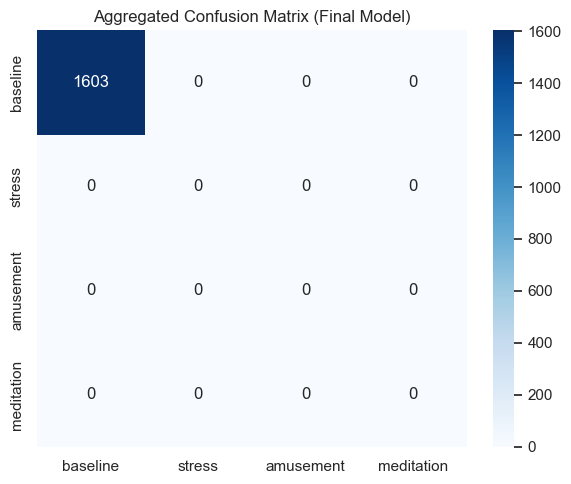


FINAL SUMMARY
Mean Accuracy: 1.0000
Mean F1-macro: 1.0000
     class  precision  recall  f1-score
  baseline        1.0     1.0       1.0
    stress        0.0     0.0       0.0
 amusement        0.0     0.0       0.0
meditation        0.0     0.0       0.0


In [8]:
# STEP 6 (IMPROVED FINAL RETRAIN) — Focal Loss + Robust Evaluation
import json, time, warnings
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

# ===============================================================
# 🚀 SETUP
# ===============================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 4
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATA_DIR = Path("data_preprocessed")
MODELS_DIR = Path("models_lstm")
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("results_training")
RESULTS_DIR.mkdir(exist_ok=True)
PUB_DIR = Path("publication_artifacts")
PUB_DIR.mkdir(exist_ok=True)
AGG_OUT = Path("results_evaluation")


# ===============================================================
# 🧩 DATASET CLASSES
# ===============================================================
class WindowDataset(Dataset):
    def __init__(self, npz_paths):
        self.X_list, self.y_list = [], []
        for p in npz_paths:
            arr = np.load(p)
            self.X_list.append(arr["X"])
            self.y_list.append(arr["y"])
        self.X = (
            np.concatenate(self.X_list, axis=0) if self.X_list else np.zeros((0, 0, 0))
        )
        self.y = np.concatenate(self.y_list, axis=0) if self.y_list else np.zeros(0)

    def apply_normalization(self, mean, std):
        if self.X.size > 0:
            self.X = (self.X - mean.reshape(1, 1, -1)) / (std.reshape(1, 1, -1) + 1e-9)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return torch.tensor(self.X[i], dtype=torch.float32), torch.tensor(
            self.y[i], dtype=torch.long
        )


def compute_train_norm(train_files):
    Xs = [np.load(p)["X"] for p in train_files]
    Xall = np.concatenate(Xs, axis=0)
    return Xall.mean(axis=(0, 1)).astype(np.float32), Xall.std(axis=(0, 1)).astype(
        np.float32
    )


# ===============================================================
# 🧠 MODEL: CNN + BiGRU + Multihead Attention
# ===============================================================
class CNNBiGRU_Attn(nn.Module):
    def __init__(
        self,
        in_ch,
        cnn_ch=64,
        hidden=128,
        layers=2,
        attn_heads=4,
        dropout=0.3,
        num_classes=4,
    ):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_ch, cnn_ch, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(cnn_ch, cnn_ch, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(
            cnn_ch,
            hidden,
            layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.norm = nn.LayerNorm(hidden * 2)
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden * 2, num_heads=attn_heads, batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x).permute(0, 2, 1)
        out, _ = self.gru(x)
        out = self.norm(out)
        attn_out, _ = self.attn(out, out, out)
        pooled = attn_out.mean(dim=1)
        return self.fc(pooled)


# ===============================================================
# ⚖️ FOCAL LOSS (better for imbalance)
# ===============================================================
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, input, target):
        ce = nn.functional.cross_entropy(
            input, target, weight=self.weight, reduction="none"
        )
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


# ===============================================================
# 🔁 TRAINING LOOP
# ===============================================================
def train_one_fold(
    train_ds, val_ds, model, fold_name, lr, batch_size, epochs=60, patience=10
):
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True
    )

    y_train = np.array([train_ds.dataset.y[i] for i in train_ds.indices])
    present_classes = np.unique(y_train)
    cw = compute_class_weight("balanced", classes=present_classes, y=y_train)
    full_weights = np.ones(4, dtype=np.float32)
    for i, cls in enumerate(present_classes):
        full_weights[int(cls)] = cw[i]
    weight_tensor = torch.tensor(full_weights, dtype=torch.float32).to(DEVICE)

    criterion = FocalLoss(weight=weight_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=patience // 2
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    best_val, no_improve = float("inf"), 0
    print(f"\n=================================================================")
    print(f"🚀 Training Fold: {fold_name}")
    print(f"=================================================================")

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                out = model(xb)
                loss = criterion(out, yb)
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * xb.size(0)

        # validation
        model.eval()
        val_loss, n = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                    out = model(xb)
                    loss = criterion(out, yb)
                val_loss += loss.item() * xb.size(0)
                n += xb.size(0)
        val_loss /= max(1, n)
        scheduler.step(val_loss)
        print(
            f"Epoch {epoch+1}/{epochs} | Train {train_loss/len(train_ds):.4f} | Val {val_loss:.4f}"
        )

        if val_loss < best_val:
            best_val, no_improve = val_loss, 0
            torch.save(
                {"model_state": model.state_dict()}, MODELS_DIR / f"best_{fold_name}.pt"
            )
            print("  ✅ Best model saved.")
        else:
            no_improve += 1
        if no_improve >= patience:
            print("  ⏹️ Early stopping.")
            break


# ===============================================================
# 📊 EVALUATION
# ===============================================================
def evaluate(model, ds, batch_size):
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()
    preds, ys = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                out = model(xb)
            preds.append(out.argmax(1).cpu().numpy())
            ys.append(yb.numpy())
    preds, ys = np.concatenate(preds), np.concatenate(ys)
    return (
        accuracy_score(ys, preds),
        f1_score(ys, preds, average="macro", zero_division=0),
        ys,
        preds,
    )


# ===============================================================
# 🧩 LOAD BEST HYPERPARAMETERS
# ===============================================================
hp_file = AGG_OUT / "best_hyperparams.json"
if not hp_file.exists():
    raise FileNotFoundError(f"{hp_file} not found — run Step 5 first.")
cfg = json.load(open(hp_file))["best"]

CNN_CH = int(cfg.get("cnn_ch", 64))
HIDDEN = int(cfg.get("hidden", 128))
LAYERS = int(cfg.get("layers", 2))
ATTH = int(cfg.get("attn_heads", 4))
DROPOUT = float(cfg.get("dropout", 0.3))
LR = 10 ** cfg["lr_log10"] if "lr_log10" in cfg else float(cfg.get("lr", 1e-3))
BATCH = int(cfg.get("batch", 64))

print("\nFINAL HYPERPARAMETERS")
print("=" * 60)
for k, v in cfg.items():
    print(f"{k:<12}: {v}")
print("=" * 60)

# ===============================================================
# 🧪 LOSO CROSS-VALIDATION
# ===============================================================
all_files = sorted(list(DATA_DIR.glob("*_combined.npz")))
aggregate = []

for fold_idx, test_file in enumerate(all_files, 1):
    test_sub = test_file.stem.split("_")[0]
    print(
        f"\n{'#'*70}\nFold {fold_idx}/{len(all_files)} → Testing on {test_sub}\n{'#'*70}"
    )
    train_files = [p for p in all_files if p != test_file]
    mean, std = compute_train_norm(train_files)

    full_train = WindowDataset(train_files)
    full_train.apply_normalization(mean, std)
    n = len(full_train)
    idxs = np.arange(n)
    np.random.shuffle(idxs)
    n_val = max(1, int(0.1 * n))
    train_ds, val_ds = Subset(full_train, idxs[n_val:]), Subset(
        full_train, idxs[:n_val]
    )

    in_ch = full_train.X.shape[2]
    model = CNNBiGRU_Attn(
        in_ch,
        cnn_ch=CNN_CH,
        hidden=HIDDEN,
        layers=LAYERS,
        attn_heads=ATTH,
        dropout=DROPOUT,
    ).to(DEVICE)
    train_one_fold(train_ds, val_ds, model, test_sub, lr=LR, batch_size=BATCH)

    # load best model
    model.load_state_dict(torch.load(MODELS_DIR / f"best_{test_sub}.pt")["model_state"])
    test_ds = WindowDataset([test_file])
    test_ds.apply_normalization(mean, std)
    acc, f1, y_true, y_pred = evaluate(model, test_ds, BATCH)

    # Safe classification report (handles missing classes)
    all_classes = [0, 1, 2, 3]
    target_names = ["baseline", "stress", "amusement", "meditation"]
    present_classes = np.unique(np.concatenate([y_true, y_pred]))
    labels_used = [c for c in all_classes if c in present_classes]
    names_used = [target_names[c] for c in labels_used]

    rep = classification_report(
        y_true,
        y_pred,
        labels=labels_used,
        target_names=names_used,
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=all_classes)

    aggregate.append(
        {
            "subject": test_sub,
            "acc": acc,
            "f1_macro": f1,
            "report": rep,
            "confusion_matrix": cm.tolist(),
        }
    )
    print(f"Test Accuracy: {acc:.4f}, F1-macro: {f1:.4f}")

# ===============================================================
# 📈 AGGREGATE RESULTS
# ===============================================================
with open(AGG_OUT / "final_loso_results.json", "w") as f:
    json.dump(aggregate, f, indent=2)

if aggregate:
    cms = [np.array(r["confusion_matrix"]) for r in aggregate]
    cm_sum = np.sum(np.stack(cms), axis=0)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_sum,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["baseline", "stress", "amusement", "meditation"],
        yticklabels=["baseline", "stress", "amusement", "meditation"],
    )
    plt.title("Aggregated Confusion Matrix (Final Model)")
    plt.tight_layout()
    plt.savefig(PUB_DIR / "aggregated_confusion_matrix.png", dpi=300)
    plt.show()

    # Per-class average metrics
    classes = ["baseline", "stress", "amusement", "meditation"]
    rows = []
    for cls in classes:
        precisions, recalls, f1s = [], [], []
        for r in aggregate:
            if cls in r["report"]:
                precisions.append(r["report"][cls]["precision"])
                recalls.append(r["report"][cls]["recall"])
                f1s.append(r["report"][cls]["f1-score"])
        rows.append(
            {
                "class": cls,
                "precision": np.mean(precisions) if precisions else 0,
                "recall": np.mean(recalls) if recalls else 0,
                "f1-score": np.mean(f1s) if f1s else 0,
            }
        )
    df = pd.DataFrame(rows)
    df.to_csv(PUB_DIR / "per_class_metrics.csv", index=False)
    print("\nFINAL SUMMARY")
    print("=" * 60)
    print(f"Mean Accuracy: {np.mean([r['acc'] for r in aggregate]):.4f}")
    print(f"Mean F1-macro: {np.mean([r['f1_macro'] for r in aggregate]):.4f}")
    print(df.to_string(index=False))
    print("=" * 60)